# 1. Decay

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}clustering/merged/5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `f'{outdir}decay/cell_*_decay.hdf5'`  ·  _other_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `'/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/vs-DNAm/integration-data/neu.majortype-transfered-from-mC.pdpkl'`  ·  _other_
- `'/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/vs-DNAm/integration-data/nonn.majortype-transfered-from-mC.pdpkl'`  ·  _other_
- `'/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/clustering/based-on-kim-20220729/cell_meta.qced.pdhdf'`  ·  _metadata_
- `'/gale/netapp/home/wtian/hba/analysis/MotifEnrich/MajorType/dmr.MajorType.rho08.dist250.filter1.repflt/qry.h5ad'`  ·  _DMR_
- `f'/gale/netapp/home/wtian/hba/analysis/DMR/DMR-results/MajorType-hyp/hypo.{xx}.bed'`  ·  _DMR_
- `f'{indir}compartment_majortype/saddle_impute_mergerawpca.npy'`  ·  _compartment_
- `f'{indir}compartment_majortype/saddle_raw_mergerawpca.npy'`  ·  _compartment_
- `f'{cemba.CEMBA_SNM3C_CELL_TYPE_ANNOTATION_PATH}/CEMBA.snm3C.Annotations.zarr/'`  ·  _ext: CEMBA_
- `f'{indir}cell_*_decay.hdf5'`  ·  _other_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
from glob import glob
import time
from scipy.stats import spearmanr, pearsonr
from itertools import cycle, islice

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [2]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{ENTEX_ROOT}/analysis/'


In [3]:
# group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# # group_meta = group_meta[['L2_any', 'L1', 'count']]
# group_meta['L1_annot'] = group_meta['L1_annot'].str.replace(' ','-').str.replace('/','_')
# annot2L1 = group_meta[['L1','L1_annot']].set_index('L1_annot')['L1'].to_dict()
# L1annot = group_meta[['L1','L1_annot']].set_index('L1')['L1_annot'].to_dict()


In [3]:
meta = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad').obs
# meta['L1'] = meta['L1'].astype(str)
# meta.loc[meta['L1']=='c7', 'L1'] = 'c35'
# meta.loc[(meta['L1']=='c35') & meta['L2_any'].isin(['c0','c10','c11']), 'L1'] = 'c36'


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
decay = pd.concat([pd.read_hdf(xx, key='data') for xx in glob(f'{outdir}decay/cell_*_decay.hdf5')], axis=0)
decay = decay.loc[meta.index]
decay = decay / decay.sum(axis=1).values[:,None]


In [5]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [27]:
(np.log2([200000,2000000,10000000,100000000])-np.log2(2500))/0.125

array([ 50.57542476,  77.15084952,  95.72627428, 122.30169904])

In [6]:
meta['short'] = decay.loc[:, (decay.columns > 50) & (decay.columns < 78)].mean(axis=1)
meta['long'] = decay.loc[:, (decay.columns > 95) & (decay.columns < 123)].mean(axis=1)
meta['ratio'] = np.log2(meta['short'] / meta['long'])


In [7]:
leg = meta.groupby('L1')['ratio'].median().sort_values().index[::-1]
selc = []
for xx in leg:
    tmp = meta.loc[meta['L1']==xx]
    selc.append(tmp.sort_values('ratio').index[::-1])
    
selc = np.concatenate(selc)
meta = meta.loc[selc]
decay = decay.loc[selc]


In [8]:
offset = [0]
count = meta['L1'].value_counts()
for xx in leg:
    offset.append(offset[-1]+count.loc[xx])

offset = np.array(offset)


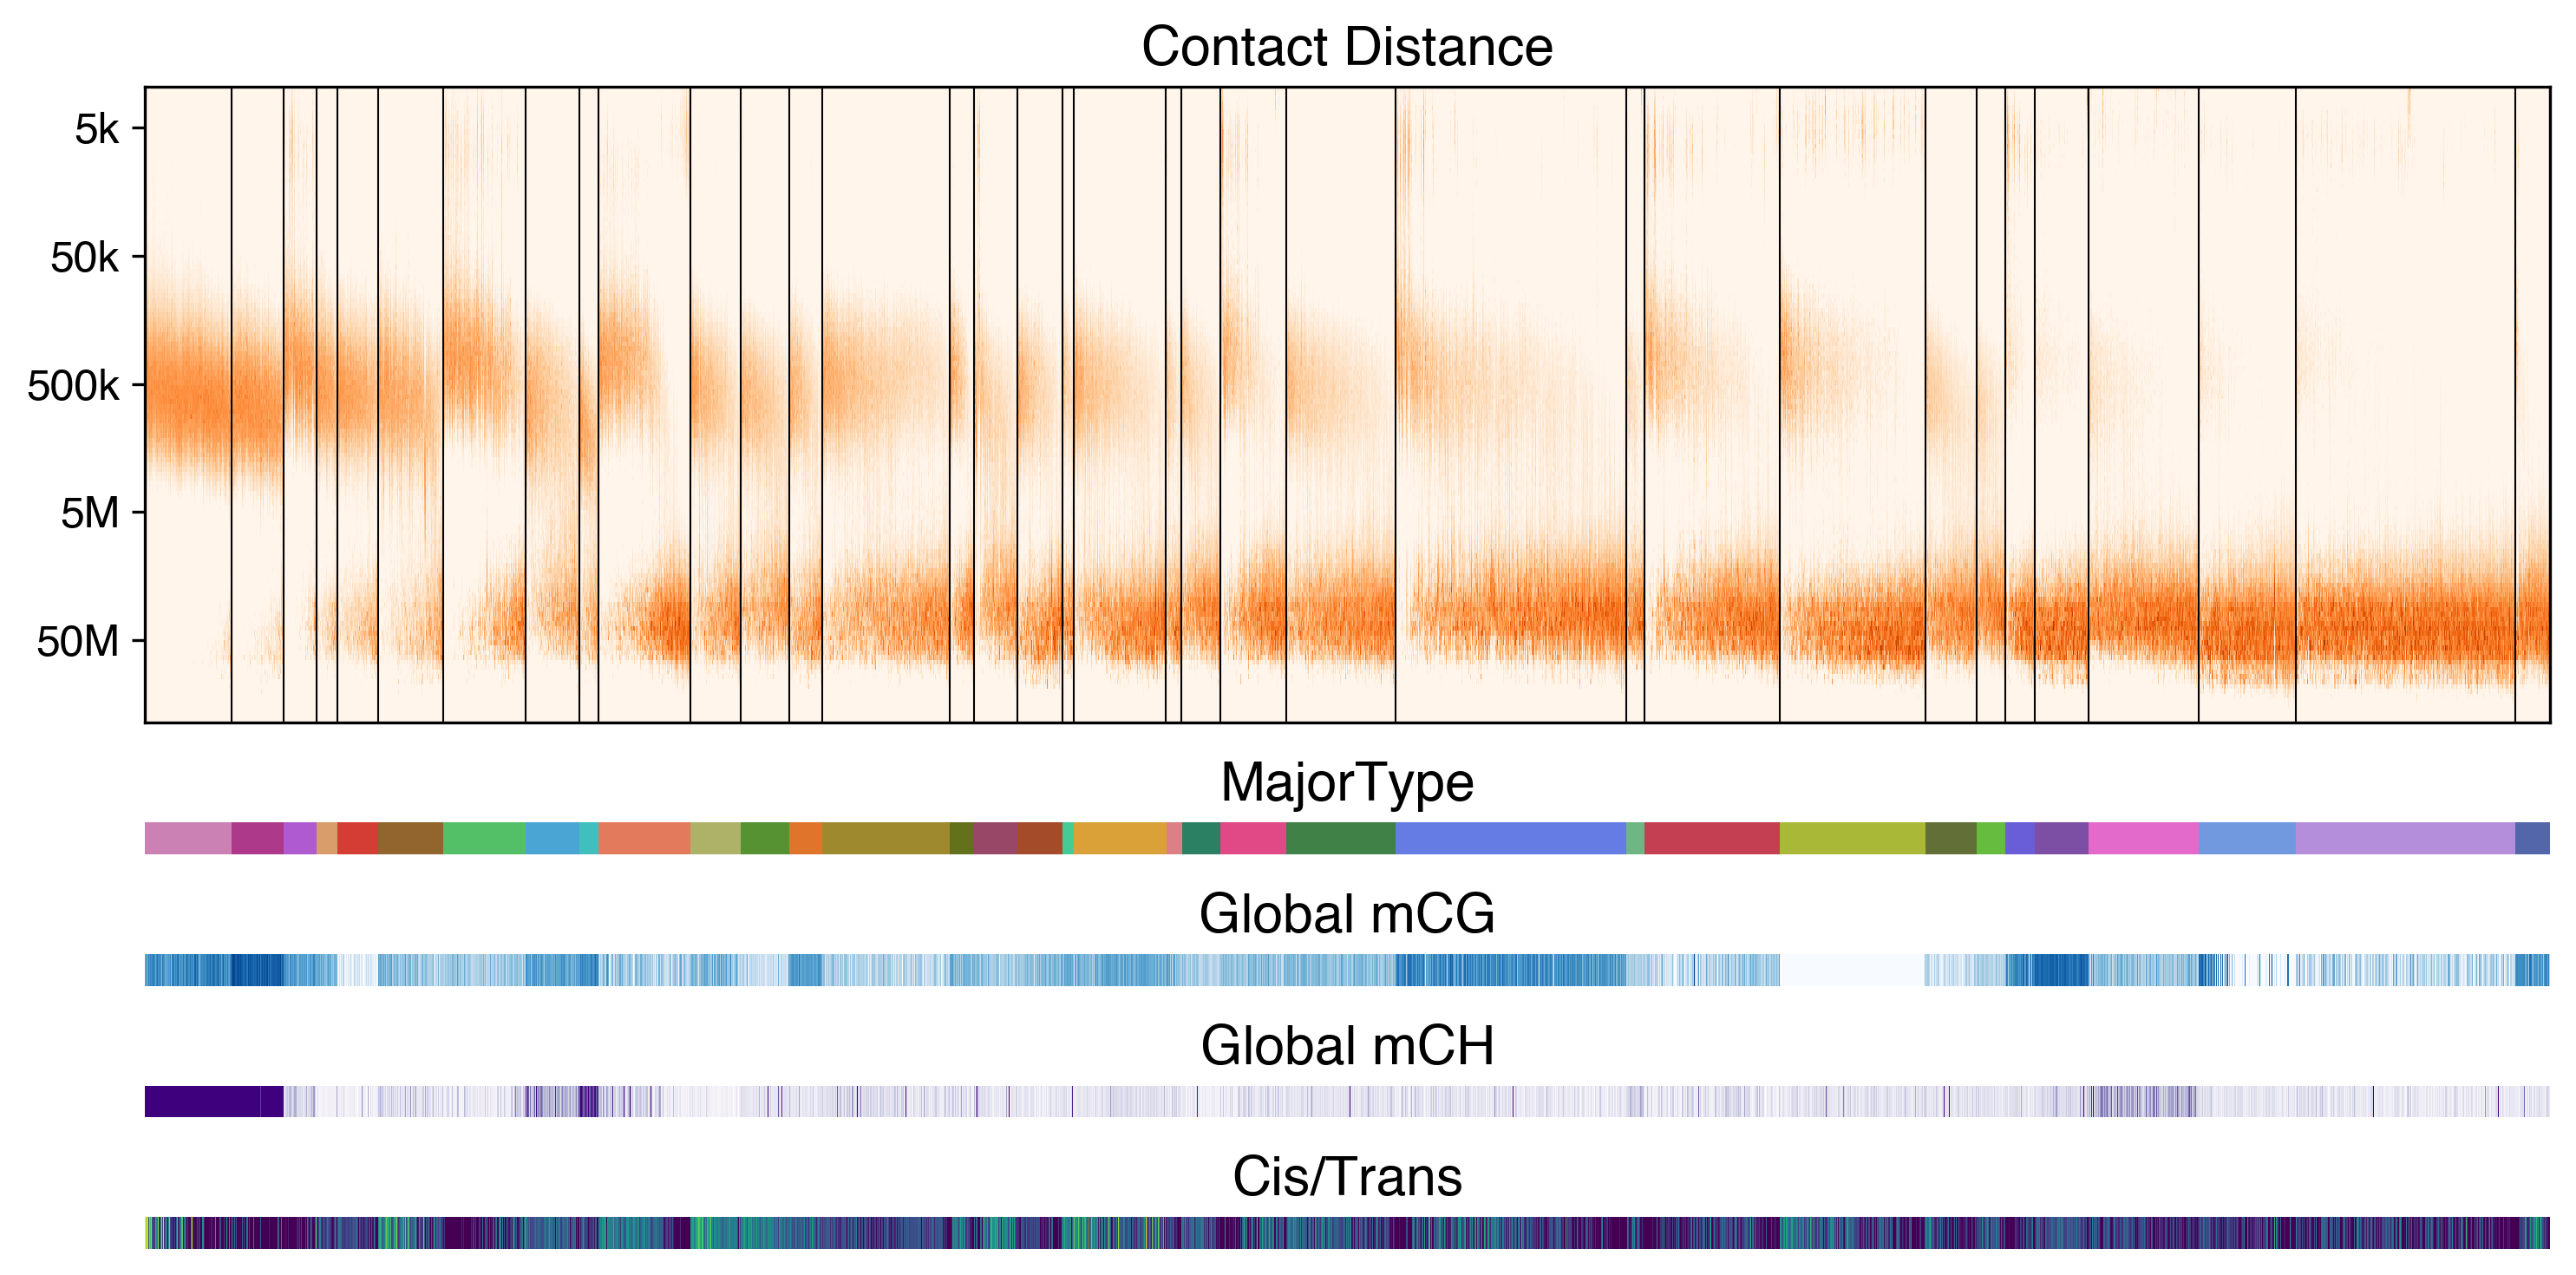

In [9]:
import matplotlib.patches as patches
from scipy.stats import zscore

fig, axes = plt.subplots(5, 1, gridspec_kw={'height_ratios': [20,1,1,1,1]}, figsize=(10,5), sharex='all', dpi=300)
ax = axes[0]
ax.imshow(zscore(decay, axis=1).T, cmap='Oranges', vmin=0, vmax=4, 
          aspect='auto', interpolation='none', rasterized=True)
ax.set_xticks([])
xticks = [5000, 50000, 500000, 5000000, 50000000]
xticklabels = ['5k', '50k', '500k', '5M', '50M']
ax.set_yticks([np.log2(xx/2500)/0.125 for xx in xticks])
ax.set_yticklabels(xticklabels, fontsize=12)
for xx in offset:
    ax.vlines(x=xx-0.5, colors='k', ymin=-0.5, ymax=decay.shape[1]-0.5, linewidths=0.5)

ax = axes[1]
ax.axis('off')
# ax.set_ylabel('MajorType', rotation=0)
for i,xx in enumerate(leg):
    rect = patches.Rectangle((offset[i], 0), offset[i+1]-offset[i], 1, linewidth=0, edgecolor='none', facecolor=L1_color[xx])
    ax.add_patch(rect)
    # ax.text(np.mean(offset[i:(i+2)]), -0.2, label, rotation=90, fontsize=10, horizontalalignment='left', verticalalignment='top')

ax = axes[2]
ax.imshow(meta['mCGFrac'].values[None, :], aspect='auto', vmin=0.65, vmax=0.85, 
          interpolation='none', cmap='Blues', rasterized=True)
ax.axis('off')

ax = axes[3]
ax.imshow(meta['mCHFrac'].values[None, :], aspect='auto', vmin=0.005, vmax=0.025, 
          interpolation='none', cmap='Purples', rasterized=True)
ax.axis('off')

ax = axes[4]
ax.imshow(np.log2(meta['Cis/Trans'].values[None, :]), aspect='auto', vmin=0, vmax=1.5, 
          interpolation='none', cmap='viridis', rasterized=True)
ax.axis('off')

for ax,xx in zip(axes, ['Contact Distance', 'MajorType', 'Global mCG', 'Global mCH', 'Cis/Trans']):
    ax.set_title(xx, fontsize=15)

plt.tight_layout()
plt.savefig(f'decay/cell_{meta.shape[0]}_majortype_decay.pdf', transparent=True, dpi=300)



In [48]:
from scipy.stats import pearsonr
pearsonr(meta['Cis/Trans'], meta['ratio'])

PearsonRResult(statistic=0.18585073066665614, pvalue=0.0)

/tmp/ipykernel_2466553/2484670072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta, x='L1', y='ratio', order=leg, ax=ax, palette=L1_color, showfliers=False)
/tmp/ipykernel_2466553/2484670072.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([L1_annot[xx] for xx in leg], rotation=-90)


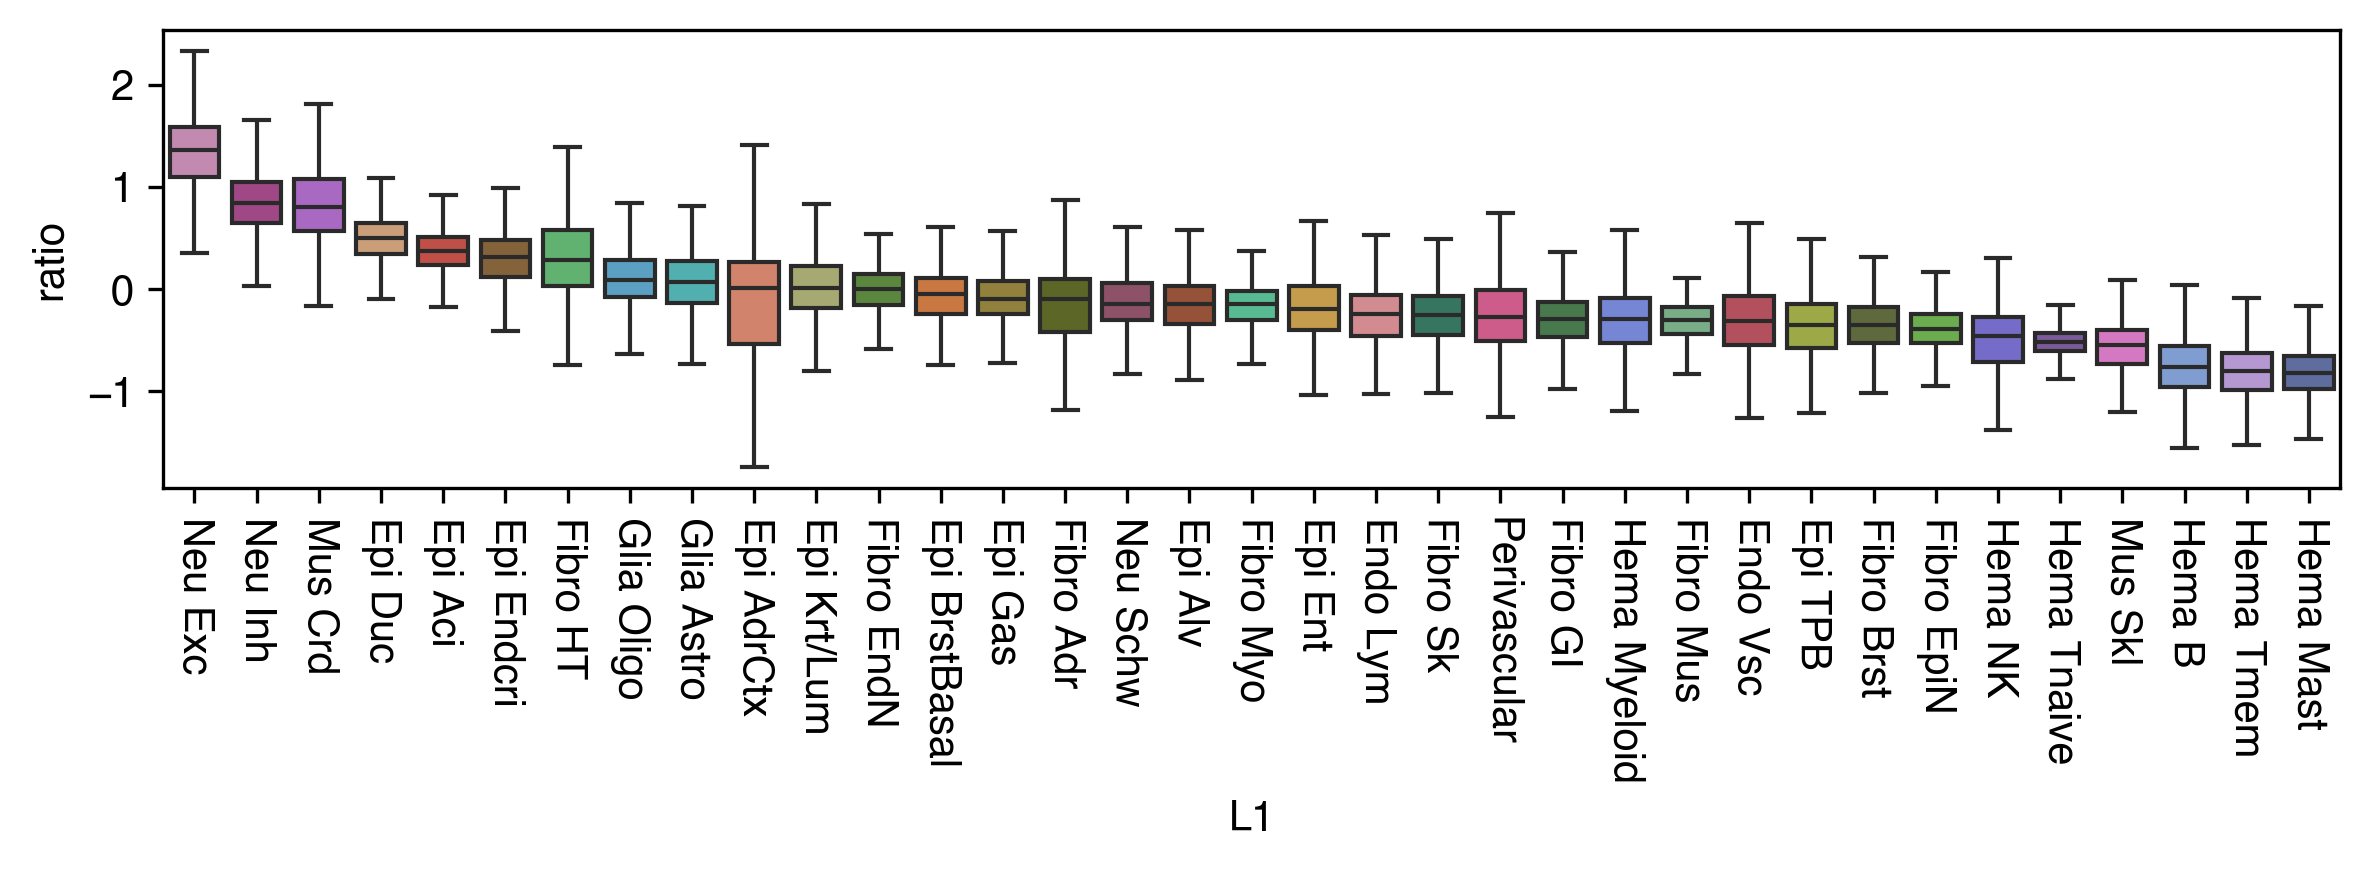

In [16]:
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
sns.boxplot(data=meta, x='L1', y='ratio', order=leg, ax=ax, palette=L1_color, showfliers=False)
ax.set_xticklabels([L1_annot[xx] for xx in leg], rotation=-90)
plt.tight_layout()
plt.savefig(f'decay/cell_{meta.shape[0]}_majortype_decay_boxplot.pdf', transparent=True)


In [8]:
L1_annot['c21'] = 'Glia Schw'

In [9]:
germ_layer = {
    # Endothelium / vasculature
    "Endo Lymphatic": "mesoderm",
    "Endo Vascular": "mesoderm",

    # Epithelia
    "Epi Acinar": "endoderm",              # e.g. pancreatic / digestive acini
    "Epi Adrenal": "mesoderm",            # adrenal cortex (epithelioid steroidogenic cells)
    "Epi Alveolar": "endoderm",
    "Epi Breast Basal": "ectoderm",
    "Epi Ductal": "ectoderm",             # mammary duct epithelium
    "Epi Endocrine": "endoderm",          # gut/pancreatic endocrine epithelia
    "Epi Enteric": "endoderm",
    "Epi Gastric": "endoderm",
    "Epi Keratinous/Luminal": "ectoderm", # epidermis / keratinocytes
    "Epi Trophoblast": "ectoderm",        # strictly trophectoderm/extraembryonic, but ectoderm-derived

    # Fibroblasts / myofibroblasts
    "Fibro Adrenal": "mesoderm",
    "Fibro Breast": "mesoderm",
    "Fibro Endoneurial": "mesoderm",
    "Fibro Epineurial": "mesoderm",
    "Fibro Gastrointestinal": "mesoderm",
    "Fibro Heart": "mesoderm",
    "Fibro Muscular": "mesoderm",
    "Myofibroblast": "mesoderm",
    "Fibro Skin": "mesoderm",

    # Glia / neurons
    "Glia Astrocyte": "ectoderm",
    "Glia Oligodendrocyte": "ectoderm",
    "Neu Excitatory": "ectoderm",
    "Neu Inhibitory": "ectoderm",
    "Glia Schwann": "ectoderm",            # neural crest–derived

    # Hematopoietic / immune
    "Hema B": "mesoderm",
    "Hema Mast": "mesoderm",
    "Hema Myeloid": "mesoderm",
    "Hema NK": "mesoderm",
    "Hema Tmem": "mesoderm",
    "Hema Tnaive": "mesoderm",

    # Muscle / mural cells
    "Mus Cardiac": "mesoderm",
    "Mus Skeletal": "mesoderm",
    "Perivascular": "mesoderm",           # pericytes / mural cells
}

In [10]:
ratio_df = pd.DataFrame(meta.groupby('L1')['ratio'].median())
ratio_df['L1_annot'] = ratio_df.index.map(L1_annot)
ratio_df['L0'] = ratio_df['L1_annot'].str.split(' ').str[0]
ratio_df['germ_layer'] = ratio_df.index.map(L1_meta['L1_annot'].to_dict()).map(germ_layer)
ratio_df['L0'].value_counts()

L0
Epi             10
Fibro            9
Hema             6
Glia             3
Endo             2
Mus              2
Neu              2
Perivascular     1
Name: count, dtype: int64

In [58]:
import itertools
from scipy.stats import ranksums
for ct1,ct2 in itertools.combinations(ratio_df['L0'].unique(), 2):
    data1 = ratio_df.loc[ratio_df['L0']==ct1, 'ratio']
    data2 = ratio_df.loc[ratio_df['L0']==ct2, 'ratio']
    if (len(data1) < 2) or (len(data2) < 2):
        continue
    stat, pval = ranksums(data1, data2)
    if pval < 0.05:
        print(f'{ct1} vs {ct2}: s={stat:.3f}, p={pval:.3e}')

Epi vs Fibro: s=2.041, p=4.123e-02
Epi vs Hema: s=3.145, p=1.658e-03
Epi vs Neu: s=-2.148, p=3.169e-02
Fibro vs Hema: s=2.828, p=4.678e-03
Fibro vs Neu: s=-2.121, p=3.389e-02
Glia vs Hema: s=2.324, p=2.014e-02
Hema vs Neu: s=-2.000, p=4.550e-02


In [15]:
import itertools
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests as FDR

pv = []
mt = []
for ct in ratio_df['L0'].unique():
    data1 = ratio_df.loc[ratio_df['L0']==ct, 'ratio']
    data2 = ratio_df.loc[ratio_df['L0']!=ct, 'ratio']
    if (len(data1) < 2) or (len(data2) < 2):
        continue
    stat, pval = ranksums(data1, data2)
    if pval < 0.05:
        print(f'{ct}: s={stat:.3f}, p={pval:.3e}')
    pv.append(pval)
    mt.append(ct)

fdr = FDR(pv, 0.01, "fdr_bh")[1]
pd.Series(fdr, index=mt).sort_values()


Epi: s=1.972, p=4.863e-02
Hema: s=-3.458, p=5.447e-04
Neu: s=2.345, p=1.902e-02


Hema     0.003813
Neu      0.066558
Epi      0.113475
Glia     0.377869
Fibro    0.636910
Endo     0.636910
Mus      0.943345
dtype: float64

In [71]:
adata = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')
adata.obs['Short/Long'] = meta['ratio'].copy()
adata.write_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
data =  pd.concat([pd.read_pickle('/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/vs-DNAm/integration-data/neu.majortype-transfered-from-mC.pdpkl'),
                  pd.read_pickle('/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/vs-DNAm/integration-data/nonn.majortype-transfered-from-mC.pdpkl'),
                  ], axis=0)
data


,Study,tsne_0,tsne_1,roi4color,pred_from_mC,pred_from_mC_prob
HBA_211005_H1930002_CX48_BL_La_2_P8-1-D8-I13,mC,-17.191321,-5.335488,AMY,Amy,1.0
HBA_211005_H1930002_CX48_BL_La_2_P8-1-D8-C1,mC,-17.216187,-5.233585,AMY,Amy,1.0
HBA_211005_H1930002_CX48_BL_La_2_P8-3-D8-M5,mC,-17.220816,-5.295431,AMY,Amy,1.0
HBA_211005_H1930002_CX48_BL_La_2_P8-1-D8-A14,mC,-17.231431,-5.293575,AMY,Amy,1.0
HBA_211005_H1930002_CX48_BL_La_2_P4-4-B6-M7,mC,-17.189190,-5.387228,AMY,Amy,1.0
...,...,...,...,...,...,...
XH_496.TTTCTGTCGGGACGTCCCTCAT,atac,-4.237938,-0.085277,A44-A45,ODC,1.0
XH_496.TTTCTGTCGGGGATACTCGTGA,atac,-3.119405,-0.911814,A44-A45,ODC,1.0
XH_496.TTTCTGTCGGGGGCATAAACGT,atac,9.439809,2.183109,A44-A45,ASC,1.0
XH_496.TTTCTGTCGGGTGACGCGGTAT,atac,9.575575,2.205444,A44-A45,ASC,1.0


In [15]:
rnameta = pd.read_hdf('/gale/netapp/home/wtian/hba/analysis/MultiModalityIntigration/RNA/clustering/based-on-kim-20220729/cell_meta.qced.pdhdf')
rnameta


,Age,Agetext,Ageunit,All_fc_analysis_id,Analysis,BarcodeTotalUMIs,CellCycle,CellCycle_G1,CellCycle_G2M,CellCycle_S,...,targetnumcells,tissue,transcriptome,unspliced_ratio,Cluster,Class,Subclass,MTG_Classifier,good,supregion
CellID,,,,,,,,,,,,,,,,,,,,,
10X357_3:TTCCTAAAGCCTGCCA,42.0,42y,years,6387,Queueing,784.0,0.001756,0.000702,0.001054,0.0,...,5000,Amygdaloid complex (AMY) - Basolateral nuclear...,hg38-final3,0.618195,467.0,Oligodendrocyte lineage,Oligodendrocyte,Oligo,True,NaN
10X357_3:TGCAGGCGTATCACCA,42.0,42y,years,6387,Queueing,708.0,0.000294,0.000000,0.000294,0.0,...,5000,Amygdaloid complex (AMY) - Basolateral nuclear...,hg38-final3,0.709032,466.0,Oligodendrocyte lineage,Oligodendrocyte,Oligo,True,NaN
10X357_4:TATTCCAGTGTTTGCA,42.0,42y,years,6391,Queueing,1330.0,0.001487,0.000406,0.001082,0.0,...,5000,Amygdaloid complex (AMY) - Basolateral nuclear...,hg38-final3,0.756793,465.0,Oligodendrocyte lineage,Oligodendrocyte,Oligo,True,NaN
10X357_4:TATTCCACAGATAAAC,42.0,42y,years,6391,Queueing,671.0,0.000958,0.000240,0.000719,0.0,...,5000,Amygdaloid complex (AMY) - Basolateral nuclear...,hg38-final3,0.755870,467.0,Oligodendrocyte lineage,Oligodendrocyte,Oligo,True,NaN
10X353_6:TTATTGCAGCCTGTCG,29.0,29y,years,6386,Queueing,516.0,0.002919,0.000584,0.002335,0.0,...,5000,Amygdaloid complex (AMY) - Basolateral nuclear...,hg38-final3,0.596030,467.0,Oligodendrocyte lineage,Oligodendrocyte,Oligo,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X230_5:GTTCCGTAGCCTGTGC,29.0,29y,years,3421,Queueing,460.0,0.002693,0.000770,0.001924,0.0,...,5000,Body of hippocampus (HiB) - Rostral DG-CA4,GRCh38-3.0.0,0.762216,522.0,Doublets/BadCells,Doublets/BadCells,NaN,False,HIF
10X230_6:GTGTTAGAGAACTTCC,29.0,29y,years,3420,Queueing,386.0,0.000000,0.000000,0.000000,0.0,...,5000,Body of hippocampus (HiB) - Rostral DG-CA4,GRCh38-3.0.0,0.695473,522.0,Doublets/BadCells,Doublets/BadCells,NaN,False,HIF
10X230_5:AAGTGAAGTATCGTAC,29.0,29y,years,3421,Queueing,304.0,0.000633,0.000000,0.000633,0.0,...,5000,Body of hippocampus (HiB) - Rostral DG-CA4,GRCh38-3.0.0,0.736542,522.0,Doublets/BadCells,Doublets/BadCells,NaN,False,HIF


In [26]:
rnameta = rnameta.loc[data.index[data['Study']=='10x']]
rnameta['pred_from_mC'] = data.loc[rnameta.index, 'pred_from_mC'].values


In [29]:
rnameta.groupby('pred_from_mC')['BarcodeTotalUMIs'].mean().sort_values()


pred_from_mC
MGC           1507.150281
OPC           1530.438910
CB            1577.102402
EC            1782.478528
PC            1875.003656
ASC           1913.715319
ODC           2094.553364
VLMC          2120.804554
HIF_Unk1      2835.054162
PKJ           2904.914740
Sst           2924.535430
DG            2991.164842
HIF_Unk2      3058.166667
Vip           3218.150187
Pvalb_ChC     3279.701401
Lamp5         3405.575989
Foxp2         3546.309323
Sncg          3614.803146
THM_MB        3845.490880
CA2           3904.791088
Lamp5_LHX6    3966.352144
Pvalb         4073.042010
L4_IT         4080.750316
CHD7          4260.011995
MSN_D1        4285.153611
MSN_D2        4356.889047
L56_NP        4406.802867
Amy           4514.198859
SubCtx        4755.717839
L6_CT         4814.384522
L23_IT        4947.680716
L6_IT_Car3    5150.352412
PN            5379.523188
L5_IT         5545.719476
L6b           5646.123165
THM_Inh       5744.640191
L6_IT         5887.079002
CA3           7135.186367

In [31]:
meta.groupby('MajorType')['ratio'].mean().sort_values()

MajorType
EC           -0.511544
PC           -0.495670
MGC          -0.428365
VLMC         -0.244641
ODC          -0.215347
ASC           0.236921
OPC           0.435832
Sst           1.036234
Pvalb_ChC     1.065168
Lamp5         1.079075
Vip           1.167030
Sncg          1.202621
Lamp5_LHX6    1.239027
Pvalb         1.307074
L4_IT         1.359731
CHD7          1.538960
Foxp2         1.570183
L23_IT        1.610786
L56_NP        1.643477
L5_IT         1.698091
L6_CT         1.755064
MSN_D2        1.827863
SubCtx        1.841502
MSN_D1        1.858230
L6_IT_Car3    1.899537
L6_IT         1.907716
L6b           1.987252
Amy           2.054128
L5_ET         2.224536
Name: ratio, dtype: float64

In [33]:
from scipy.stats import pearsonr
pearsonr(meta.groupby('MajorType')['ratio'].mean().loc[leg], rnameta.groupby('pred_from_mC')['BarcodeTotalUMIs'].mean().loc[leg])


(0.8731596483389721, 6.4613468246853e-10)

In [91]:
motifad = anndata.read_h5ad('/gale/netapp/home/wtian/hba/analysis/MotifEnrich/MajorType/dmr.MajorType.rho08.dist250.filter1.repflt/qry.h5ad')
motifad


AnnData object with n_obs × n_vars = 1887429 × 746

In [97]:
motifad.obs['dmr'] = ['_'.join(xx.split('_')[:-1]) for xx in motifad.obs.index]


In [114]:
for xx in leg:
    tmp = pd.read_csv(f'/gale/netapp/home/wtian/hba/analysis/DMR/DMR-results/MajorType-hyp/hypo.{xx}.bed', sep='\t', header=None, index_col=3).index
    motifad.obs[xx] = motifad.obs['dmr'].isin(tmp)
    print(xx)
    

L5_ET
Amy
MSN_D2
L6b
L6_IT
MSN_D1
L6_IT_Car3
CHD7
L6_CT
L5_IT
L23_IT
SubCtx
Foxp2
L56_NP
L4_IT
Pvalb
Sncg
Lamp5_LHX6
Vip
Lamp5
Pvalb_ChC
Sst
OPC
ASC
ODC
VLMC
MGC
EC


In [118]:
ctmotif = pd.DataFrame(index=motifad.var.index, columns=leg)
count = {}
for xx in leg:
    ctmotif[xx] = motifad.X[motifad.obs[xx].values].sum(axis=0).A1
    count[xx] = motifad.obs[xx].sum()
    print(xx)
    

L5_ET
Amy
MSN_D2
L6b
L6_IT
MSN_D1
L6_IT_Car3
CHD7
L6_CT
L5_IT
L23_IT
SubCtx
Foxp2
L56_NP
L4_IT
Pvalb
Sncg
Lamp5_LHX6
Vip
Lamp5
Pvalb_ChC
Sst
OPC
ASC
ODC
VLMC
MGC
EC


In [123]:
ctmotif

MajorType,L5_ET,Amy,MSN_D2,L6b,L6_IT,MSN_D1,L6_IT_Car3,CHD7,L6_CT,L5_IT,...,Vip,Lamp5,Pvalb_ChC,Sst,OPC,ASC,ODC,VLMC,MGC,EC
id,,,,,,,,,,,,,,,,,,,,,
MA0002.2,212336,197899,128823,183403,189883,121627,155322,56659,167265,118764,...,46469,87346,64887,30383,193916,154319,245620,296044,263881,340005
MA0003.4,94241,87725,59721,79281,89233,55749,75254,28368,78475,54361,...,21799,35807,28753,11677,101771,86350,116741,150214,134299,160612
MA0004.1,170956,161450,107815,148109,155471,101348,128581,47664,138476,97776,...,38327,67686,50845,24215,159122,125377,197106,239484,215410,272840
MA0006.1,210285,195647,128857,180590,188465,121622,154299,55922,165968,117622,...,45665,85408,63641,29991,191179,152521,241040,288178,257305,330048
MA0007.3,18936,17084,10868,15950,16507,10204,13593,5207,14818,10710,...,4572,7437,5620,2562,19857,15677,23798,26597,23410,30519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MA1654.1,2152,1887,1330,1724,2002,1215,1712,636,1830,1269,...,468,726,559,222,2340,1988,2609,3352,3250,3673
MA1655.1,146385,136935,88648,127493,133545,83412,110002,43356,119704,84087,...,34532,61470,46040,21596,143653,115841,175678,210568,184617,233068
MA1656.1,81162,76235,49995,70477,78318,46678,64157,25241,67531,47076,...,20254,33074,24819,10114,87290,74340,101015,125703,111829,136326


In [125]:
ctmotif = ctmotif / pd.Series(count)

In [126]:
ctmotif.loc['MA0139.1']

MajorType
L5_ET         0.132237
Amy           0.144074
MSN_D2        0.137590
L6b           0.129571
L6_IT         0.147115
MSN_D1        0.134583
L6_IT_Car3    0.149571
CHD7          0.182074
L6_CT         0.151211
L5_IT         0.149601
L23_IT        0.154947
SubCtx        0.164827
Foxp2         0.135944
L56_NP        0.165907
L4_IT         0.170968
Pvalb         0.125340
Sncg          0.120822
Lamp5_LHX6    0.110156
Vip           0.165769
Lamp5         0.119768
Pvalb_ChC     0.136436
Sst           0.104135
OPC           0.186344
ASC           0.196349
ODC           0.167484
VLMC          0.171902
MGC           0.175700
EC            0.159372
Name: MA0139.1, dtype: float64

In [130]:
meta.groupby('MajorType')['ratio'].mean().loc[leg]

MajorType
L5_ET         12.936391
Amy           11.586932
MSN_D2        11.036784
L6b           10.638600
L6_IT         10.376866
MSN_D1        10.244872
L6_IT_Car3    10.009854
CHD7           9.281814
L6_CT          9.114454
L5_IT          8.920203
L23_IT         8.596515
SubCtx         8.493078
Foxp2          8.470961
L56_NP         8.186145
L4_IT          6.778601
Pvalb          6.732397
Sncg           6.343550
Lamp5_LHX6     6.258996
Vip            5.985944
Lamp5          5.600183
Pvalb_ChC      5.572600
Sst            5.488075
OPC            3.612811
ASC            3.153866
ODC            2.298176
VLMC           2.079371
MGC            2.002575
EC             1.989937
Name: ratio, dtype: float64

In [134]:
from scipy.stats import spearmanr
pearsonr(meta.groupby('MajorType')['ratio'].mean().loc[leg], ctmotif.loc['MA0139.1'])


(-0.3578226631238664, 0.06154826327231145)

In [20]:
ratio = meta.groupby(hue)['ratio'].mean().loc[leg]


In [58]:
leg0 = ['L23_IT', 'L4_IT', 'L5_IT', 'L6_IT', 'L6_IT_Car3', 'L56_NP', 'L6_CT', 'L6b', 'L5_ET', 'Amy', 
       'Lamp5', 'Lamp5_LHX6', 'Sncg', 'Vip', 'Pvalb', 'Pvalb_ChC', 'Sst', 'CHD7', 
       'MSN_D1', 'MSN_D2', 'Foxp2', 'SubCtx', 
       'ASC', 'ODC', 'OPC', 'MGC', 'PC', 'EC', 'VLMC'
      ]
legname = ['L2/3-IT', 'L4-IT', 'L5-IT', 'L6-IT', 'L6-IT-Car3', 'L5/6-NP', 'L6-CT', 'L6b', 'L5-ET', 'Amy-Exc', 
       'Lamp5', 'Lamp5-Lhx6', 'Sncg', 'Vip', 'Pvalb', 'Pvalb-ChC', 'Sst', 'Chd7', 
       'MSN-D1', 'MSN-D2', 'Foxp2', 'SubCtx-Cplx', 
       'ASC', 'ODC', 'OPC', 'MGC', 'PC', 'EC', 'VLMC'
      ]



In [44]:
sad = np.load(f'{indir}compartment_majortype/saddle_impute_mergerawpca.npy')
ws = 10
compstr = [[sad[i][:ws, :ws].mean(), sad[i][-ws:, -ws:].mean(), 
            np.mean([sad[i][:ws, -ws:].mean(), sad[i][-ws:, :ws].mean()])]
            for i in range(len(leg)+1)]
compstr = pd.DataFrame(compstr, index=leg0+['merged'], columns=['BB', 'AA', 'Inter'])
compstr['Strength'] = compstr[['BB','AA']].mean(axis=1) / compstr['Inter']


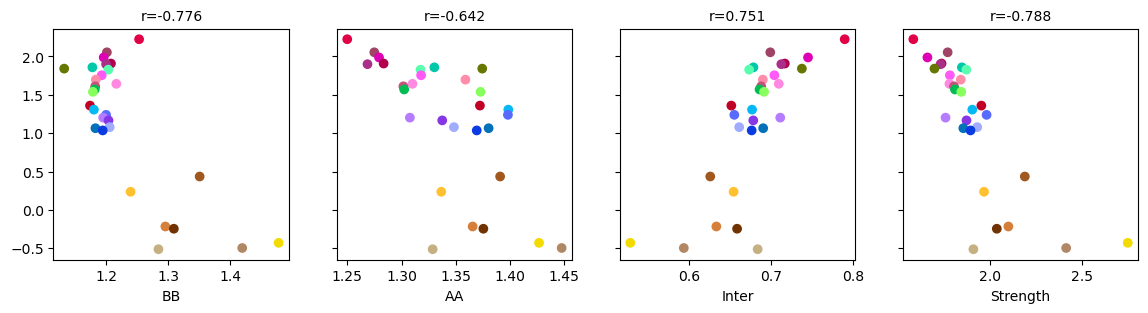

In [46]:
# impute

fig, axes = plt.subplots(1, 4, figsize=(14,3), sharey='all')
for i,x in enumerate(compstr.columns):
    ax = axes[i]
    ax.scatter(compstr.loc[leg, x], ratio, c=pd.Series(leg).map(colordict))
#     for k,xx in enumerate(leg0):
#         ax.text(compstr.loc[xx, x], ratio.loc[xx], legname[k])
    ax.set_title(f'r={np.around(pearsonr(compstr.loc[leg, x], ratio)[0], decimals=3)}', fontsize=10)
    ax.set_xlabel(x, fontsize=10)
    
# plt.tight_layout()
plt.savefig(f'{indir}/plot/celltype_ratio_compstr_impute_corr.pdf', transparent=True)


In [124]:
for i,x in enumerate(compstr.columns):
    print(pearsonr(compstr.loc[leg, x], ratio))


(-0.7762692484365825, 7.455693655179459e-07)
(-0.6423581911681051, 0.00017199932956680274)
(0.7510620754485567, 2.6756580060990923e-06)
(-0.7883356225005858, 3.811698818638039e-07)


In [47]:
sad = np.load(f'{indir}compartment_majortype/saddle_raw_mergerawpca.npy')
ws = 10
compstr = [[sad[i][:ws, :ws].mean(), sad[i][-ws:, -ws:].mean(), 
            np.mean([sad[i][:ws, -ws:].mean(), sad[i][-ws:, :ws].mean()])]
            for i in range(len(leg)+1)]
compstr = pd.DataFrame(compstr, index=leg0+['merged'], columns=['BB', 'AA', 'Inter'])
compstr['Strength'] = compstr[['BB','AA']].mean(axis=1) / compstr['Inter']


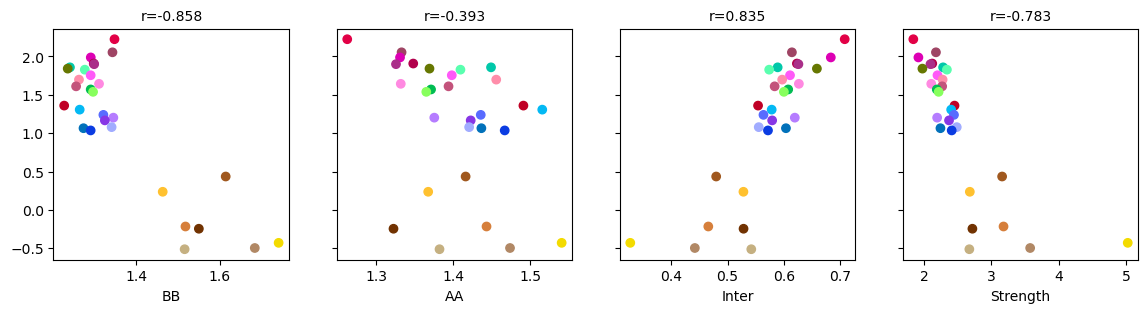

In [48]:
# raw

fig, axes = plt.subplots(1, 4, figsize=(14,3), sharey='all')
for i,x in enumerate(compstr.columns):
    ax = axes[i]
    ax.scatter(compstr.loc[leg, x], ratio, c=pd.Series(leg).map(colordict))
#     for k,xx in enumerate(leg0):
#         ax.text(compstr.loc[xx, x], ratio.loc[xx], legname[k])
    ax.set_title(f'r={np.around(pearsonr(compstr.loc[leg, x], ratio)[0], decimals=3)}', fontsize=10)
    ax.set_xlabel(x, fontsize=10)
    
# plt.tight_layout()
plt.savefig(f'{indir}/plot/celltype_ratio_compstr_raw_corr.pdf', transparent=True)



In [121]:
for i,x in enumerate(compstr.columns):
    print(pearsonr(compstr.loc[leg, x], ratio))


(-0.8576089359970456, 2.796463213405639e-09)
(-0.3931056867974746, 0.03489332195204961)
(0.8352935445052595, 1.7367571106855158e-08)
(-0.7825824278518084, 5.276133139380073e-07)


## Liu 2021

In [3]:
indir = '/gale/netapp/entex/HBA/snm3C/decay/Liu2021/'

In [4]:
from wmb import cemba
meta = cemba.get_m3c_mapping_metric()
meta

,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,Sample,...,CisLongRatio,TransContact,TransRatio,Technology,InputReads,PassBasicQC,PlateNormCov,CEMBARegion,MajorRegion,SubRegion
cell,,,,,,,,,,,,,,,,,,,,,
CEMBA191126_9J_1-CEMBA191126_9J_2-A1-AD002,0.004221,0.704487,0.008457,3351057,HPF-2,CEMBA191126_9J_1,0,1,9,CEMBA191126_9J,...,0.226522,203408,0.117162,snm3C-seq,5325450,True,2.681377,9J,HPF,HIP
CEMBA191126_9J_1-CEMBA191126_9J_2-A1-AD004,0.004694,0.711583,0.008305,7339138,HPF-2,CEMBA191126_9J_1,1,0,9,CEMBA191126_9J,...,0.225642,464628,0.121757,snm3C-seq,11527562,True,5.872473,9J,HPF,HIP
CEMBA191126_9J_1-CEMBA191126_9J_2-A1-AD006,0.004626,0.712702,0.009139,1562166,HPF-2,CEMBA191126_9J_1,1,1,9,CEMBA191126_9J,...,0.258975,101302,0.125669,snm3C-seq,2600118,True,1.249980,9J,HPF,HIP
CEMBA191126_9J_1-CEMBA191126_9J_2-A1-AD007,0.003694,0.662486,0.004810,1427822,HPF-2,CEMBA191126_9J_2,0,0,9,CEMBA191126_9J,...,0.164245,81962,0.111194,snm3C-seq,2278846,True,1.256558,9J,HPF,HIP
CEMBA191126_9J_1-CEMBA191126_9J_2-A1-AD008,0.004966,0.713724,0.009948,1394985,HPF-2,CEMBA191126_9J_2,0,1,9,CEMBA191126_9J,...,0.246095,85557,0.119172,snm3C-seq,2372930,True,1.227659,9J,HPF,HIP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEMBA3C_18A3C_R2_P3-4-B6-O8,0.005491,0.717344,0.010345,2444290,CB-2,CEMBA3C_18A3C_R2_P3,7,14,18,CEMBA3C_18A3C_R2,...,0.199120,151285,0.119620,snm3C-seq,4331410,True,1.082704,18A3C,CB,CB
CEMBA3C_18A3C_R2_P3-4-B6-P19,0.005794,0.719815,0.010979,2176294,CB-2,CEMBA3C_18A3C_R2_P3,18,15,18,CEMBA3C_18A3C_R2,...,0.196232,140641,0.125097,snm3C-seq,3909684,True,0.963994,18A3C,CB,CB
CEMBA3C_18A3C_R2_P3-4-B6-P20,0.004305,0.714725,0.008890,1334611,CB-2,CEMBA3C_18A3C_R2_P3,19,15,18,CEMBA3C_18A3C_R2,...,0.185141,70487,0.103228,snm3C-seq,2243776,True,0.591169,18A3C,CB,CB


In [5]:
contact_table = pd.read_csv(cemba.CEMBA_SNM3C_CONTACT_PATH, index_col=0)
contact_table = contact_table[contact_table['0'].str.split('/').str[6].isin([f'HIP{i+1}' for i in range(4)])]


In [6]:
import xarray as xr
annot = xr.open_zarr(f'{cemba.CEMBA_SNM3C_CELL_TYPE_ANNOTATION_PATH}/CEMBA.snm3C.Annotations.zarr/')
annot

<xarray.Dataset>
Dimensions:             (cell: 176003, L4Region_cat: 2363, l1_tsne: 2, l1_umap: 2, l2_tsne: 2, l2_umap: 2, l3_tsne: 2, l3_umap: 2, l4_tsne: 2, l4_umap: 2)
Coordinates:
  * L4Region_cat        (L4Region_cat) <U18 'c0_c0_c0_c0_r0' ... 'c9_c9_c3_c3...
  * cell                (cell) <U45 'CEMBA191126_9J_1-CEMBA191126_9J_2-A1-AD0...
  * l1_tsne             (l1_tsne) <U9 'l1_tsne_0' 'l1_tsne_1'
  * l1_umap             (l1_umap) <U9 'l1_umap_0' 'l1_umap_1'
  * l2_tsne             (l2_tsne) <U9 'l2_tsne_0' 'l2_tsne_1'
  * l2_umap             (l2_umap) <U9 'l2_umap_0' 'l2_umap_1'
  * l3_tsne             (l3_tsne) <U9 'l3_tsne_0' 'l3_tsne_1'
  * l3_umap             (l3_umap) <U9 'l3_umap_0' 'l3_umap_1'
  * l4_tsne             (l4_tsne) <U9 'l4_tsne_0' 'l4_tsne_1'
  * l4_umap             (l4_umap) <U9 'l4_umap_0' 'l4_umap_1'
Data variables: (12/15)
    CellType            (cell) <U32 dask.array<chunksize=(176003,), meta=np.ndarray>
    L1                  (cell) <U3 dask.array<chunksize=(176003,), meta=np.ndarray>
    L2                  (cell) <U3 dask.array<chunksize=(176003,), meta=np.ndarray>
    L3                  (cell) <U3 dask.array<chunksize=(176003,), meta=np.ndarray>
    L4                  (cell) <U3 dask.array<chunksize=(176003,), meta=np.ndarray>
    L4Region            (cell) <U3 dask.array<chunksize=(176003,), meta=np.ndarray>
    ...                  ...
    l2_tsne_coord       (cell, l2_tsne) float32 dask.array<chunksize=(176003, 2), meta=np.ndarray>
    l2_umap_coord       (cell, l2_umap) float32 dask.array<chunksize=(176003, 2), meta=np.ndarray>
    l3_tsne_coord       (cell, l3_tsne) float32 dask.array<chunksize=(176003, 2), meta=np.ndarray>
    l3_umap_coord       (cell, l3_umap) float32 dask.array<chunksize=(176003, 2), meta=np.ndarray>
    l4_tsne_coord       (cell, l4_tsne) float32 dask.array<chunksize=(176003, 2), meta=np.ndarray>
    l4_umap_coord       (cell, l4_umap) float32 dask.array<chunksize=(176003, 2), meta=np.ndarray>
Attributes:
    L1_coord:           ['l1_tsne', 'l1_umap']
    L2_coord:           ['l2_tsne', 'l2_umap']
    L3_coord:           ['l3_tsne', 'l3_umap']
    L4Region_coord:     ['l4_tsne', 'l4_umap']
    L4_coord:           ['l4_tsne', 'l4_umap']
    cluster_data_var:   ['L1', 'L2', 'L3', 'L4', 'L4Region', 'CellType']
    cluster_hierarchy:  [['L1', 'L2', 'L3', 'L4', 'L4Region'], ['CellType']]

In [7]:
selc = np.sort(annot.get_index('cell').intersection(meta.index & contact_table.index))
print(len(selc))


5218


/gale/netapp/home/zhoujt/miniconda3/envs/scarches/lib/python3.7/site-packages/ipykernel-6.4.1-py3.7.egg/ipykernel_launcher.py:1: FutureWarning: Index.__and__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__and__.  Use index.intersection(other) instead
  """Entry point for launching an IPython kernel.


In [8]:
meta = meta.loc[selc]
meta['CellType'] = annot['CellType'].to_pandas().loc[selc]
contact_table = contact_table.loc[selc]


In [9]:
contact_table.to_csv(f'{indir}contact_table.tsv', sep='\t', header=None)


In [10]:
# decay_list = glob('/gale/netapp/home/wtian/hba/mapping2/hba_m3c*_*_*/scool/decay.hdf5')
# decay = pd.concat([pd.read_hdf(xx, key='data') for xx in decay_list], axis=0)
decay = pd.concat([pd.read_hdf(xx, key='data') for xx in glob(f'{indir}cell_*_decay.hdf5')], axis=0)
decay


,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,128,129
CEMBA191126_8J_1-CEMBA191126_8J_2-A10-AD001,838,917,923,1041,1049,1079,1070,1087,1079,1129,...,1082,972,710,474,379,271,259,239,118,5
CEMBA191126_8J_1-CEMBA191126_8J_2-A10-AD002,360,337,393,427,410,396,415,420,464,501,...,454,386,398,251,173,113,134,73,17,1
CEMBA191126_8J_1-CEMBA191126_8J_2-A10-AD006,889,915,946,949,1047,963,1035,995,1031,1057,...,1487,1067,754,526,394,368,167,135,81,1
CEMBA191126_8J_1-CEMBA191126_8J_2-A10-AD007,680,640,634,670,703,670,717,728,714,735,...,617,614,460,275,209,143,151,112,34,1
CEMBA191126_8J_1-CEMBA191126_8J_2-A10-AD008,312,349,354,328,345,388,370,389,380,387,...,447,450,319,215,120,124,100,63,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEMBA191127_9H_3-CEMBA191127_9H_4-H8-AD007,1159,1191,1109,1260,1270,1204,1316,1320,1328,1318,...,963,865,619,446,323,322,175,134,77,15
CEMBA191127_9H_3-CEMBA191127_9H_4-H8-AD012,1109,1239,1259,1274,1355,1367,1402,1400,1490,1394,...,1117,850,551,537,339,301,232,124,45,7
CEMBA191127_9H_3-CEMBA191127_9H_4-H9-AD007,1853,1897,1836,1923,2132,2039,2008,2076,2058,1980,...,940,1013,780,503,553,250,247,104,98,23
CEMBA191127_9H_3-CEMBA191127_9H_4-H9-AD010,868,959,922,967,999,990,1048,1036,1003,983,...,798,930,640,443,394,296,153,115,56,38


In [11]:
count = meta['CellType'].value_counts()

selc = decay.index & meta.index[meta['CellType'].isin(count.index[count>20])]
decay = decay.loc[selc]
meta = meta.loc[selc]
print(meta.shape)

(5082, 22)


/gale/netapp/home/zhoujt/miniconda3/envs/scarches/lib/python3.7/site-packages/ipykernel-6.4.1-py3.7.egg/ipykernel_launcher.py:3: FutureWarning: Index.__and__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__and__.  Use index.intersection(other) instead
  This is separate from the ipykernel package so we can avoid doing imports until


In [12]:
decay = decay / decay.sum(axis=1)[:,None]


/gale/netapp/home/zhoujt/miniconda3/envs/scarches/lib/python3.7/site-packages/ipykernel-6.4.1-py3.7.egg/ipykernel_launcher.py:1: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  """Entry point for launching an IPython kernel.


In [13]:
hue = 'CellType'
# colordict = hba_data.internal.celltype.CellType.majortype_palette()
count = count[count>20]
colordict = {xx:yy for xx,yy in zip(count.index, sns.color_palette('tab20', count.shape[0]))}
rowcolor = [colordict[xx] for xx in meta[hue]]
# rowcolor = np.array([rowcolor, meta['mCHFrac'].values]).T


In [15]:
np.log2(np.array([100000, 1500000, 20000000, 50000000])/2500)/0.125

array([ 42.57542476,  73.83054952, 103.72627428, 114.30169904])

In [14]:
meta['short'] = decay.loc[:, (decay.columns > 42) & (decay.columns < 74)].mean(axis=1)
meta['long'] = decay.loc[:, (decay.columns > 103) & (decay.columns < 114)].mean(axis=1)
meta['ratio'] = np.log2(meta['short'] / meta['long'])


In [15]:
leg0 = count.index


In [16]:
len(leg0)

20

In [17]:
meta = meta.sample(frac=1)


In [18]:
leg = meta.groupby(hue)['ratio'].median().sort_values().index[::-1]


In [19]:
# leg = ['Neuron', 'Neonatal Neuron 1', 'Neonatal Neuron 2', 
#        'Cortical L2–5 Pyramidal Cell', 'Cortical L6 Pyramidal Cell', 'Interneuron', 'Medium Spiny Neuron',
#        'Hippocampal Pyramidal Cell', 'Hippocampal Granule Cell',
#        'Neonatal Astrocyte', 'Adult Astrocyte', 
#        'Oligodendrocyte Progenitor', 'Mature Oligodendrocyte', 'Microglia Etc.',
#        'Unknown'
#       ]

meta = pd.concat([meta[meta[hue]==xx] for xx in leg], axis=0)
meta


,mCCCFrac,mCGFrac,mCHFrac,FinalmCReads,DissectionRegion,Plate,Col384,Row384,Slice,Sample,...,InputReads,PassBasicQC,PlateNormCov,CEMBARegion,MajorRegion,SubRegion,CellType,short,long,ratio
CEMBA191127_9H_1-CEMBA191127_9H_2-E5-AD002,0.005490,0.748052,0.016909,3059497,HPF-2,CEMBA191127_9H_1,8,9,9,CEMBA191127_9H,...,4770608,True,1068.446656,9H,HPF,HIP,Sncg Gaba,0.010922,0.006216,0.813273
CEMBA191127_8E_1-CEMBA191127_8E_2-A1-AD010,0.007641,0.791745,0.031496,785552,HPF-1,CEMBA191127_8E_2,1,0,8,CEMBA191127_8E,...,1281618,True,780.091360,8E,HPF,HIP,Sncg Gaba,0.010183,0.004540,1.165397
CEMBA191127_11F_5-CEMBA191126_HCV_9-H8-AD008,0.007111,0.789343,0.026207,1508188,HPF-3,CEMBA191126_HCV_9,14,15,10,CEMBA191126_HCV,...,2588150,True,168.795523,10D3C,HPF,HIP,Sncg Gaba,0.011634,0.003654,1.670891
CEMBA191126_HCV_7-CEMBA191126_HCV_8-F2-AD002,0.006639,0.780830,0.026208,1694059,HPF-3,CEMBA191126_HCV_7,2,11,10,CEMBA191126_HCV,...,2632716,True,78.596038,10D3C,HPF,HIP,Sncg Gaba,0.011012,0.004542,1.277754
CEMBA191126_HCV_5-CEMBA191126_HCV_6-A3-AD007,0.007719,0.790909,0.032496,1424787,HPF-3,CEMBA191126_HCV_6,4,0,10,CEMBA191126_HCV,...,2206076,True,2.109670,10D3C,HPF,HIP,Sncg Gaba,0.011222,0.003686,1.606122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEMBA191127_10F_3-CEMBA191127_10F_4-F12-AD001,0.004471,0.695138,0.005538,1222889,HPF-2,CEMBA191127_10F_3,22,10,10,CEMBA191127_10F,...,2157972,True,191.810682,10F,HPF,HIP,Microglia NN,0.006423,0.013642,-1.086840
CEMBA191126_HCV_5-CEMBA191126_HCV_6-B7-AD008,0.004197,0.719499,0.004973,1275457,HPF-3,CEMBA191126_HCV_6,12,3,10,CEMBA191126_HCV,...,2077050,True,1.888559,10D3C,HPF,HIP,Microglia NN,0.006539,0.015163,-1.213512
CEMBA191127_11F_5-CEMBA191126_HCV_9-D2-AD004,0.004504,0.716945,0.005678,1669339,Cortex-10,CEMBA191127_11F_5,3,6,11,CEMBA191127_11F,...,2576106,True,111.803563,11F,HPF,HIP,Microglia NN,0.007294,0.013608,-0.899655
CEMBA191126_8J_1-CEMBA191126_8J_2-A10-AD008,0.004064,0.670301,0.005129,1007709,HPF-1,CEMBA191126_8J_2,18,1,8,CEMBA191126_8J,...,1593662,True,0.805774,8J,HPF,HIP,Microglia NN,0.006934,0.014221,-1.036222


In [20]:
decay = decay.loc[meta.index]


In [21]:
offset = [0]
count = meta[hue].value_counts().loc[leg].values
for i in range(len(leg)):
    offset.append(offset[-1]+count[i])

offset = np.array(offset)


In [22]:
meta['Cis/Trans'] = meta['CisLongContact'] / meta['TransContact']

/gale/netapp/home/zhoujt/miniconda3/envs/scarches/lib/python3.7/site-packages/ipykernel-6.4.1-py3.7.egg/ipykernel_launcher.py:28: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


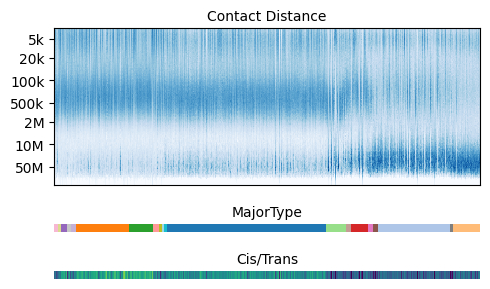

In [23]:
import matplotlib.patches as patches
from scipy.stats import zscore

fig, axes = plt.subplots(3, 1, gridspec_kw={'height_ratios': [20,1,1]}, figsize=(5,3), sharex='all')
ax = axes[0]
ax.imshow(zscore(decay, axis=1).T, cmap='Blues', aspect='auto', interpolation='none', vmin=-2, vmax=4)
ax.set_xticks([])
ax.set_yticks([np.log2(xx/2500)/0.125 for xx in [5000, 20000, 100000, 500000, 2000000, 10000000, 50000000]])
ax.set_yticklabels(['5k', '20k', '100k', '500k', '2M', '10M', '50M'])

# ax = axes[1]
# ax.imshow(meta['Cis/Trans'].values[:,None], aspect='auto', interpolation='none', cmap='bwr')
# ax.axis('off')

# ax = axes[2]
# ax.imshow(meta['mCHFrac'].values[:,None], aspect='auto', interpolation='none', vmax=0.03)
# ax.axis('off')

ax = axes[1]
ax.axis('off')
# ax.set_ylabel('MajorType', rotation=0)
for i,label in enumerate(leg):
    rect = patches.Rectangle((offset[i], 0), offset[i+1]-offset[i], 1, linewidth=0, edgecolor='none', facecolor=colordict[label])
    ax.add_patch(rect)
    # ax.text(np.mean(offset[i:(i+2)]), -0.2, label, rotation=90, fontsize=10, horizontalalignment='left', verticalalignment='top')

ax = axes[2]
ax.imshow(np.log2(meta['Cis/Trans'][None, :]), vmin=0, vmax=2, cmap='viridis', aspect='auto', interpolation='none')
ax.axis('off')

for ax,xx in zip(axes, ['Contact Distance', 'MajorType', 'Cis/Trans']):
    ax.set_title(xx, fontsize=10)

plt.tight_layout()
plt.savefig(f'{indir}../plot/cell_{meta.shape[0]}_majortype_decay.pdf', transparent=True, dpi=300)



In [24]:
f'{indir}../plot/cell_{meta.shape[0]}_majortype_decay.pdf'

'/gale/netapp/entex/HBA/snm3C/decay/Liu2021/../plot/cell_5082_majortype_decay.pdf'

In [176]:
from scipy.stats import pearsonr
pearsonr(meta['Cis/Trans'], meta['ratio'])

(0.730151733899249, 0.0)

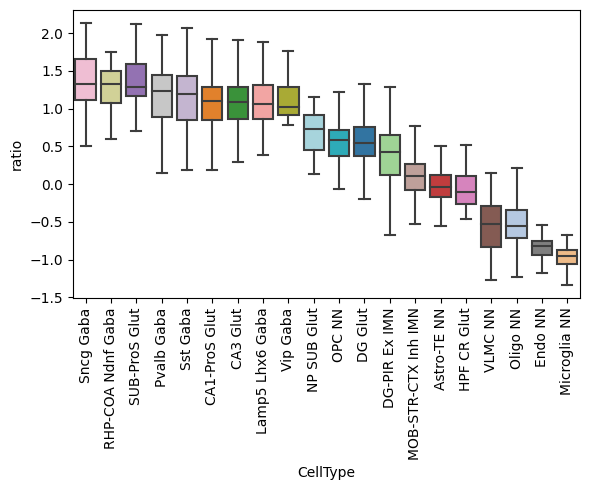

In [187]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=meta, x=hue, y='ratio', order=leg, ax=ax, palette=colordict, showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.savefig(f'{indir}../plot/cell_{meta.shape[0]}_majortype_decay_boxplot.pdf', transparent=True, dpi=300)
